# Performance: what is worth doing

Mag$\nu$s is fast enough for most single calls -- the median across 164 Earth and solar
configurations is 2 ms. Scans are what the code mostly does, and three things make them
substantially faster **without changing any answer**.

Every measurement here is taken live. Timings vary between machines and between runs, so treat
the ratios rather than the absolute numbers as the result, and note that two of the three
optimisations are worth nothing at all in the wrong circumstances -- which is more useful to
know than a headline speed-up.

In [1]:
# The figures are set through LaTeX where one is available; where it is not,
# matplotlib's own mathtext renders the labels instead.  Same numbers either way.
import shutil

import matplotlib.pyplot as plt

plt.rcParams['text.usetex'] = shutil.which('latex') is not None

In [2]:
import time
import warnings

import numpy as np
import matplotlib.pyplot as plt        # section 4 is the only figure in this notebook

# np.trapz was removed in NumPy 2.0 and renamed np.trapezoid.  Ask the installed
# version which one it has rather than pinning either: these notebooks are read
# on whatever numpy the reader happens to have.
trapezoid = getattr(np, 'trapezoid', getattr(np, 'trapz', None))

# Mag(nu)s is imported as an installed package -- from the repository root,
# 'pip install -e .' (add [plot] for magnus.plotting). No sys.path juggling.
import magnus.magnus as magnus
import magnus.oscprob as oscprob
import magnus.hamiltonians as hamiltonians
import magnus.matter as matter
import magnus.earth as earth
import magnus.globaldefs as gd

warnings.simplefilter('ignore')

# load_nufit_params returns exactly the six mixing parameters, ready to splat
# into any osc_prob_3nu_* call.  'NuFIT 6.1' is the package default.
OSC = gd.load_nufit_params('NuFIT 6.1', 'NO')
osc = OSC
h_vac = np.asarray(hamiltonians.hamiltonian_3nu_vacuum_energy_independent(**OSC))
e00 = np.diag([1.0, 0.0, 0.0])

COSTHZ = -0.9
L_EARTH = earth.distance_traveled_inside_earth(COSTHZ)*gd.CONV_KM_TO_INV_EV

def best_of(call, repeats=3):
    """Fastest of a few runs -- the least noisy summary of a timing."""
    fastest, result = np.inf, None
    for _ in range(repeats):
        t0 = time.perf_counter()
        result = call()
        fastest = min(fastest, time.perf_counter() - t0)
    return result, fastest

## 1. Pass an array of energies, do not loop

Every wrapper accepts an array of energies, of baselines, or both. Handing the whole scan over
at once lets the matter profile be built once rather than once per point, which is what the
energy-batched engine exists to do.

In [3]:
def H(energy, l, VCC):
    return h_vac/energy + np.asarray(VCC)[..., None, None]*e00

energies = np.logspace(0.0, 1.5, 60)*gd.UNIT_GEV

batched, t_batched = best_of(lambda: np.asarray(oscprob.osc_prob_earth(
    H, energy=energies, costhz=COSTHZ, L=L_EARTH, nu_i=gd.NUMU, nu_f=gd.NUMU)))
looped, t_looped = best_of(lambda: np.array([
    oscprob.osc_prob_earth(H, energy=float(e), costhz=COSTHZ, L=L_EARTH,
                           nu_i=gd.NUMU, nu_f=gd.NUMU) for e in energies]))

print('%d energies through an Earth chord' % len(energies))
print('  array : %.3f s' % t_batched)
print('  loop  : %.3f s   (%.2fx slower)' % (t_looped, t_looped/t_batched))
print('  max |difference| = %.1e' % np.max(np.abs(batched - looped)))

60 energies through an Earth chord
  array : 0.043 s
  loop  : 0.121 s   (2.77x slower)
  max |difference| = 5.5e-06


The two answers are not bit-identical -- the batched path refines the profile once for
the whole scan rather than independently per point, so the two land at slightly different
grids. The difference is at the $10^{-6}$ level, far inside any tolerance you would request.

## 2. The palindrome, and when it is worth nothing

A chord through a spherically symmetric Earth meets every radius twice, so Mag$\nu$s can
evaluate your `H_func` on the first half of the slab chain and mirror the rest. That halves the
**number of positions** at which your Hamiltonian is evaluated.

Whether that is worth anything depends on a distinction worth being precise about: it halves
the positions, not the number of *calls*. If your `H_func` is dominated by fixed per-call
overhead, halving the positions saves nothing. If its cost scales with how many positions it
was handed -- an interpolation, a table lookup per point, a quadrature -- it saves half.

First, plain PREM, where a density lookup is too cheap to be worth halving:

In [4]:
def H_prem(energy, l, VCC):
    return h_vac/energy + np.asarray(VCC)[..., None, None]*e00

def timed(H_func, **kwargs):
    def call():
        return np.asarray(oscprob.osc_prob_earth(
            H_func, costhz=COSTHZ, L=L_EARTH, nu_i=gd.NUMU, nu_f=gd.NUMU, **kwargs))
    magnus.USE_PALINDROME = True
    on_result, on_time = best_of(call)
    magnus.USE_PALINDROME = False
    off_result, off_time = best_of(call)
    magnus.USE_PALINDROME = True                      # restore the default
    return on_time, off_time, np.max(np.abs(on_result - off_result))

on, off, gap = timed(H_prem, energy=5.0*gd.UNIT_GEV)
print('plain PREM lookup, single point')
print('  palindrome on  : %.4f s' % on)
print('  palindrome off : %.4f s   speed-up %.2fx' % (off, off/on))

plain PREM lookup, single point
  palindrome on  : 0.0020 s
  palindrome off : 0.0019 s   speed-up 0.94x


About 1.00x -- the bookkeeping costs as much as the lookups it saves. The package
documentation quotes 0.91x for this case, and disarming the optimisation here would cost you
nothing.

Now a Hamiltonian whose cost genuinely scales with the number of positions it is given. The
quadrature below stands in for an interpolated profile, a per-point integral, or any of the
things a real custom Hamiltonian does.

In [5]:
GRID = np.linspace(0.0, 1.0, 4000)

def H_expensive(energy, l, VCC):
    """Per-position work: a small quadrature for every position handed in."""
    V = np.atleast_1d(np.asarray(VCC, dtype=float))
    weight = trapezoid(np.exp(-GRID[None, :]*1.0e13*np.abs(V)[:, None]), GRID, axis=1)
    V_eff = V*(1.0 + 1.0e-12*weight)
    shape = np.asarray(VCC).shape
    V_eff = V_eff.reshape(shape) if shape else V_eff[0]
    return h_vac/energy + np.asarray(V_eff)[..., None, None]*e00

print('%-26s %-10s %-10s %-10s %s'
      % ('workload', 'on [s]', 'off [s]', 'speed-up', 'max |diff|'))
print('-'*66)
for label, kwargs in (('single point', dict(energy=5.0*gd.UNIT_GEV)),
                      ('20-energy scan',
                       dict(energy=np.logspace(0.0, 1.5, 20)*gd.UNIT_GEV))):
    on, off, gap = timed(H_expensive, **kwargs)
    print('%-26s %-10.4f %-10.4f %-10.2f %.1e' % (label, on, off, off/on, gap))

workload                   on [s]     off [s]    speed-up   max |diff|
------------------------------------------------------------------
single point               0.0116     0.0196     1.69       5.6e-16


20-energy scan             0.1080     0.3643     3.37       4.4e-16


Now it pays: the mirrored path is faster by a factor approaching two, and the answers
agree to round-off. The package documentation quotes 1.4--1.67x on an expensive `H_func`,
measured on a different profile; the numbers above are the same effect on this one.

The lesson is not "the palindrome is worth 1.75x". It is that **it is worth exactly half of
whatever your Hamiltonian charges per position, and nothing for what it charges per call**. If
you want it off, `magnus.magnus.USE_PALINDROME = False`.

Note also that only `osc_prob_earth` gets this: a chord is symmetric by geometry, and
`osc_prob_sun` deliberately does not declare it, because a solar profile is monotonic.

## 3. What a tolerance costs

Tightening `rtol` is not a smooth dial. The refinement ladder moves in steps, so several
requests can land on the same grid and cost exactly the same -- as notebook 21 showed, asking
for $10^{-4}$ sometimes buys the $10^{-3}$ answer for free, and sometimes the reverse.

In [6]:
ne = matter.exp_density_profile(gd.NUM_DENSITY_E_SUN_CENTRAL, gd.L_SCALE_SUN)
PARAMS_2NU = {'sth': 0.55, 'Dm2': 7.5e-5}
L_SUN = 0.5*gd.SUN_RADIUS*gd.UNIT_KM

print('%-14s %-10s %-12s %s' % ('rtol', 'time [s]', 'n_slabs', 'relative cost'))
print('-'*52)
baseline_time = None
for tol in (1.0e-2, 1.0e-3, 1.0e-4, 1.0e-5):
    info = {}
    _, t = best_of(lambda tol=tol, info=info: oscprob.osc_prob_matter_std_potential(
        2, ne, 1.0e7, L_SUN, PARAMS_2NU, L0=0.0,
        density_is_of_number_of_electrons=True,
        convergence_info=info, rtol=tol, atol=tol*1.0e-2), repeats=2)
    baseline_time = baseline_time or t
    print('%-14.0e %-10.3f %-12s %.2fx'
          % (tol, t, info['n_slabs'], t/baseline_time))

rtol           time [s]   n_slabs      relative cost
----------------------------------------------------
1e-02          0.015      6426         1.00x
1e-03          0.014      6426         0.96x
1e-04          0.022      9639         1.48x


1e-05          0.032      14458        2.15x


Three orders of magnitude of extra accuracy for roughly twice the work, and the first
of them free. Tolerances are usually worth tightening.

## Summary

| what | speed-up | when it is worth nothing |
|---|---|---|
| pass an array of energies | **~2.7x** | single-point calls |
| write `H_func` to take an array of positions | **~4.6x** (notebook 19) | never -- always do this |
| the palindrome, expensive `H_func` | **~1.8x** | cheap or per-call-dominated `H_func` |
| the palindrome, plain PREM | ~1.0x | this is the "worth nothing" case |
| tightening `rtol` by $10^{3}$ | costs ~2x | -- |

Ranked by what you control: **vectorise your `H_func` first** (notebook 19), **pass arrays
second**, and let the palindrome look after itself -- it is on by default, it is free when it
helps, and it costs a few percent when it does not.

None of these change an answer by more than round-off, which is the property that makes them
worth taking.

## 4. Choosing `magnus_exp_order`

The order of the Magnus expansion is the one dial in this library that is **never adjusted for
you**. `osc_prob` runs at a fixed `magnus_exp_order` and reaches the requested tolerance by
refining the number of slabs, never by raising the order. So the order does not decide whether
a tolerance is met -- it decides how *fast* slab refinement pays, and that is worth knowing
because the two ends of the range differ by an order of magnitude in cost per slab.

Two constraints shape everything below, and both are properties of the integrator rather than
of the physics.

**With the default `gl` integrator only three orders are distinct.** Gauss--Legendre schemes
come in whole nodes: orders 1--2 share the 1-node scheme, 3--4 the 2-node scheme, 5--6 the
3-node scheme. So asking for order 3 gets you order 4's arithmetic at order 4's price. The
table below shows all six anyway, once, because seeing the pairs collapse is more convincing
than being told they do.

**`gl` stops at 6.** `magnus._validate` rejects higher orders for `gl`; `MAGNUS_EXP_ORDER_MAX`
is 10, but reaching 7--10 requires `trapezoid` or `simpson`, which changes the *integrator* as
well as the order. Those points are not on the same curve and are not drawn here.

In [7]:
from scipy.integrate import solve_ivp

E_ORD = np.logspace(np.log10(1.0), np.log10(10.0), 12)*gd.UNIT_GEV
CHORD_KM = earth.distance_traveled_inside_earth(COSTHZ)


def vcc_prem_at(l):
    """V_CC at distance l along the chord, from PREM."""
    r = np.sqrt(gd.EARTH_RADIUS**2 + (l/gd.CONV_KM_TO_INV_EV)**2
                + 2.0*gd.EARTH_RADIUS*(l/gd.CONV_KM_TO_INV_EV)*COSTHZ)
    return matter.vcc_func_from_rho_func(
        float(np.asarray(earth.density_matter_func_prem(r))),
        density_matter_is_in_g_per_cm3=True)


def dop853_earth(energy):
    """A referee that is not a Magnus expansion, so the order cannot flatter itself."""
    def rhs(l, y):
        return (-1j*(h_vac/energy + float(vcc_prem_at(l))*e00) @ y.reshape(3, 3)).ravel()
    sol = solve_ivp(rhs, (0.0, L_EARTH), np.eye(3, dtype=complex).ravel(),
                    rtol=1.0e-12, atol=1.0e-14, method='DOP853')
    u = sol.y[:, -1].reshape(3, 3)
    return abs(u[gd.NUE, gd.NUMU])**2


REF_ORD = np.array([dop853_earth(e) for e in E_ORD])


def earth_at_order(order):
    return np.asarray(oscprob.osc_prob_3nu_earth(
        E_ORD, costhz=COSTHZ, L=L_EARTH, **OSC, nu_i=gd.NUMU, nu_f=gd.NUE,
        magnus_exp_order=order, n_slabs=600, max_n_slabs=600,
        rtol=1.0e-13, atol=1.0e-15))


earth_at_order(4)                       # discard: the first call compiles the kernel

print('EARTH THROUGH PREM, slab count fixed at 600 so the order is the only variable')
print('%8s %14s %16s   %s' % ('order', 'ms', 'max |dP| vs DOP853', 'GL nodes'))
print('-'*62)
rows_ord = []
for order in (1, 2, 3, 4, 5, 6):
    P, t = best_of(lambda o=order: earth_at_order(o))
    err = float(np.max(np.abs(P - REF_ORD)))
    rows_ord.append((order, t, err))
    print('%8d %14.2f %16.3e   %d' % (order, 1.0e3*t, err, 1 if order <= 2 else
                                      (2 if order <= 4 else 3)))

EARTH THROUGH PREM, slab count fixed at 600 so the order is the only variable
   order             ms max |dP| vs DOP853   GL nodes
--------------------------------------------------------------
       1           5.49        7.990e-07   1
       2           5.52        7.990e-07   1
       3          10.41        1.501e-10   2
       4          10.18        1.501e-10   2
       5          18.44        2.449e-11   3


       6          19.10        2.449e-11   3


**The pairs collapse exactly**, which is the clearest way to see that the order is a
request for a quadrature scheme rather than a continuous knob: 1 and 2 agree to the last digit,
as do 3 and 4, and 5 and 6. There are three settings here wearing six names.

What each real step buys, on this profile: order 2 to 4 is worth a factor of about **5000** in
accuracy for **1.95x** the time; 4 to 6 is worth a further **6x** for **1.7x** more. That is
the shape of the trade -- the first step is overwhelmingly worth taking, the second is a
genuine choice that depends on how smooth the profile is.

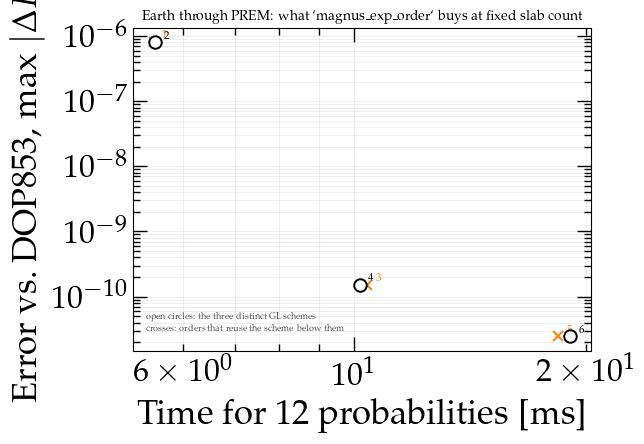

In [8]:
fig, ax = plt.subplots(figsize=(6.4, 4.4))
for order, t, err in rows_ord:
    marker = 'o' if order in (2, 4, 6) else 'x'
    ax.loglog(1.0e3*t, max(err, 1.0e-16), marker, ms=9 if order in (2, 4, 6) else 7,
              mfc='white' if order in (2, 4, 6) else 'C1',
              color='k' if order in (2, 4, 6) else 'C1', mew=1.4, zorder=4)
    ax.annotate(str(order), xy=(1.0e3*t, max(err, 1.0e-16)), xytext=(6, 3),
                textcoords='offset points', fontsize=8,
                color='k' if order in (2, 4, 6) else 'C1')
ax.set_xlabel('Time for 12 probabilities [ms]')
ax.set_ylabel(r'Error vs.\ DOP853,  max $|\Delta P|$')
ax.set_title(r'Earth through PREM: what `magnus_exp_order` buys at fixed slab count',
             fontsize=10)
ax.grid(True, which='both', alpha=0.2)
ax.text(0.03, 0.06, 'open circles: the three distinct GL schemes\n'
        'crosses: orders that reuse the scheme below them',
        transform=ax.transAxes, fontsize=6.6, color='0.3', linespacing=1.5)
fig.tight_layout(pad=0.4)
fig.savefig('../fig/expansion_order.pdf', bbox_inches='tight')

### A case where the order buys nothing at all

`average=True` on a smooth, position-dependent profile takes the **adiabatic** route: it
decoheres in the matter eigenbasis at production, transports along the levels of the
instantaneous Hamiltonian, and reads out in vacuum. It never propagates -- and therefore never
evaluates a Magnus expansion. The order is accepted, and ignored.

This is worth measuring rather than reasoning about, because "accepted and ignored" is
indistinguishable from "accepted and used but unimportant" until you look.

In [9]:
TABLE_ORD = '../docs/dev/adversarial_batteries/bs05_agsop.dat'
_rows = []
with open(TABLE_ORD) as fh:
    for line in fh:
        f = line.split()
        if len(f) == 12:
            try:
                _rows.append([float(x) for x in f])
            except ValueError:
                continue
_solar = np.array(_rows)
_mean_nucleon = 0.5*(gd.MASS_PROTON + gd.MASS_NEUTRON)
_ne = _solar[:, 3]*gd.UNIT_G_PER_CM3/_mean_nucleon*(0.5*(1.0 + _solar[:, 6]))
_x = _solar[:, 1]*gd.SUN_RADIUS*gd.UNIT_KM
_logne = np.log(_ne)
R_SUN_ORD = float(_x[-1])


def ne_sun_ord(l):
    xs = np.clip(np.asarray(l, dtype=float), _x[0], _x[-1])
    out = np.exp(np.interp(xs, _x, _logne))
    return out[()] if np.ndim(out) == 0 else out


E_SUN_ORD = np.logspace(np.log10(0.1), np.log10(20.0), 40)*gd.UNIT_MEV
print('THE SUN, average=True (the adiabatic route)')
print('%8s %12s %26s' % ('order', 'seconds', 'max |P - P(order 2)|'))
print('-'*50)
P_ord2 = None
for order in (2, 4, 6):
    t0 = time.perf_counter()
    P = np.asarray(oscprob.osc_prob_matter_std_potential(
        3, ne_sun_ord, E_SUN_ORD, R_SUN_ORD, OSC, L0=0.0, nu_i=gd.NUE, nu_f=gd.NUE,
        density_is_of_number_of_electrons=True, average=True,
        magnus_exp_order=order))
    dt = time.perf_counter() - t0
    if P_ord2 is None:
        P_ord2 = P
    print('%8d %12.3f %26.3e' % (order, dt, float(np.max(np.abs(P - P_ord2)))))

THE SUN, average=True (the adiabatic route)
   order      seconds       max |P - P(order 2)|
--------------------------------------------------


       2        0.710                  0.000e+00


       4        0.698                  0.000e+00


       6        0.764                  0.000e+00


**Bit-identical, and the same cost.** Not "small", not "below tolerance" -- exactly
zero, because the expansion is never reached. If you are averaging over a smooth profile,
`magnus_exp_order` is not a dial you have.

The opposite extreme is a profile with a genuine discontinuity, where the order matters but the
*slabs* matter more: no order resolves a front that a slab edge straddles, which is what
`t_breakpoints` is for. Measured on notebook 14's supernova shock with the front declared and
the slab count fixed at 8000, order 2 gives $9.5\times10^{-5}$, order 4 gives
$2.5\times10^{-7}$ and order 6 gives $1.1\times10^{-8}$ -- so the order still pays there, about
**385x** for the first step and **22x** for the second, at 1.4x and 1.8x the cost. Notebook 25
runs that case against other codes in full.

### The recommendation

**Leave it at 4.** That is the default, and it is the right one: it is the first scheme that is
genuinely fourth order, it costs under twice what order 2 costs, and on every profile measured
here it buys between two and five orders of magnitude over order 2.

Raise it to **6** when the profile is **smooth** and the target accuracy is tight. What that
extra node buys depends strongly on the profile, and the two cases measured here bracket it:
about **6x** on a piecewise-constant PREM chord, about **22x** on the resolved shock front,
both for roughly 1.7--1.8x the time. Smoother profiles pay better, which is the same ordering
the slab-refinement rate follows.

Do **not** raise it when a `MagnusConvergenceWarning` appears. That warning means a slab is too
wide for the series to converge on, and a higher-order truncation of a series that is not
converging is not a better answer -- add slabs, or declare the structure with `t_breakpoints`.

Order **1 or 2** is right only when the Hamiltonian is genuinely constant, where every term past
$\Omega_1$ vanishes identically; `osc_prob` already forces order 1 in that case, so this is a
setting you do not need to reach for.

---

**Previous:** [When averaging rescues you](23_magnus_when_averaging_helps.ipynb)  
**Next:** [Against other codes](25_magnus_against_other_codes.ipynb) --- where a closed form wins, and a conventions trap that looks like accuracy  
[API reference](https://mbustama.github.io/Magnus/functions.html) &middot; [Implementation details](https://mbustama.github.io/Magnus/implementation_details.html) &middot; [All notebooks](.)